<a href="https://colab.research.google.com/github/mufadah/2026_Kecerdasan_Buatan/blob/main/Jobsheet09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latihan 1: Decision Tree (Dataset Iris)

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

try:
    # 1. Ubah dataset jadi Pandas DataFrame
    df_iris = pd.read_csv('Iris.csv')

    # 2. Lihat informasi dan 5 data teratas
    print("--- Info Dataset ---")
    df_iris.info()
    print("\n--- 5 Data Teratas ---")
    display(df_iris.head())

    # 3. Hapus kolom Id karena tidak diperlukan
    if 'Id' in df_iris.columns:
        df_iris = df_iris.drop('Id', axis=1)

    # 4. Pisahkan atribut (X) dan label (y)
    X = df_iris.iloc[:, :-1] # Atribut: sepal length, sepal width, petal length, petal width
    y = df_iris.iloc[:, -1]  # Label: spesies

    # Membagi data testing dan training (asumsi rasio umum 80:20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 5. Definisikan dan latih model menggunakan data latih
    tree_model = DecisionTreeClassifier(random_state=42)
    tree_model.fit(X_train, y_train)

    # 6. Pengujian dan cek akurasi
    y_pred = tree_model.predict(X_test)
    akurasi = accuracy_score(y_test, y_pred)
    print(f"\nAkurasi Model Decision Tree: {akurasi * 100:.2f}%")

    # 7. Prediksi spesies baru (sepal_len=6.2, sepal_wid=3.4, petal_len=5.4, petal_wid=2.3)
    data_baru = [[6.2, 3.4, 5.4, 2.3]]
    prediksi_bunga = tree_model.predict(data_baru)
    print(f"Prediksi spesies untuk data baru: {prediksi_bunga[0]}")

    # 8. Visualisasi dengan Graphviz
    export_graphviz(
        tree_model,
        out_file="iris_tree.dot",
        feature_names=X.columns,
        class_names=y.unique().astype(str),
        rounded=True,
        filled=True
    )
    print("\nFile 'iris_tree.dot' berhasil dibuat! Silakan cek di panel folder kiri Colab.")

except FileNotFoundError:
    print("Error: File 'Iris.csv' belum ditemukan. Silakan upload terlebih dahulu.")

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

--- 5 Data Teratas ---


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Akurasi Model Decision Tree: 100.00%
Prediksi spesies untuk data baru: Iris-virginica

File 'iris_tree.dot' berhasil dibuat! Silakan cek di panel folder kiri Colab.


# Latihan 2: Linear Regression (Data Dummy)

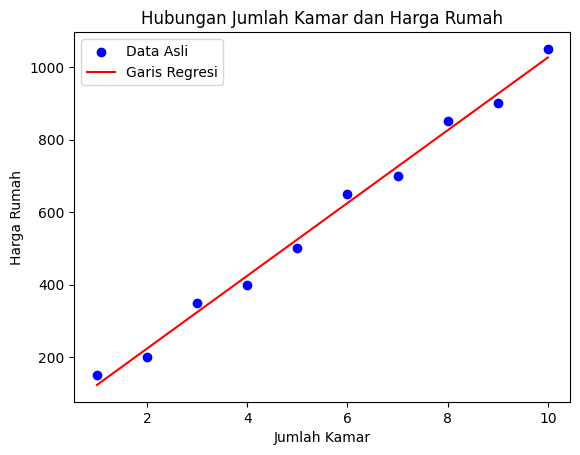

Prediksi harga untuk kamar [3 5 8]: [324.24242424 524.84848485 825.75757576]
Tingkat Akurasi (Score) Linear Regression: 0.9925


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Buat data dummy dengan numpy array
# X = Jumlah kamar, Y = Harga rumah (misal dalam ratusan juta)
kamar = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
harga = np.array([150, 200, 350, 400, 500, 650, 700, 850, 900, 1050])

# 2. Latih model dengan fungsi fit()
lin_reg = LinearRegression()
lin_reg.fit(kamar, harga)

# 3. Tampilkan scatter plot data asli dan plot garis penyesuaian model
plt.scatter(kamar, harga, color='blue', label='Data Asli')
plt.plot(kamar, lin_reg.predict(kamar), color='red', label='Garis Regresi')
plt.xlabel('Jumlah Kamar')
plt.ylabel('Harga Rumah')
plt.title('Hubungan Jumlah Kamar dan Harga Rumah')
plt.legend()
plt.show()

# 4. Lakukan pengujian terhadap data testing
kamar_test = np.array([3, 5, 8]).reshape(-1, 1) # contoh data testing
prediksi_harga = lin_reg.predict(kamar_test)
print(f"Prediksi harga untuk kamar {kamar_test.flatten()}: {prediksi_harga}")

# 5. Gunakan fungsi score() untuk melihat tingkat akurasi (R-squared)
akurasi_regresi = lin_reg.score(kamar, harga)
print(f"Tingkat Akurasi (Score) Linear Regression: {akurasi_regresi:.4f}")

# Latihan 3: Logistic Regression (Dataset Social_Network_Ads)

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

try:
    # 1. Unggah dan ubah ke dataframes pandas
    df_ads = pd.read_csv('Social_Network_Ads.csv')

    # 2. Melihat 5 baris pertama dan info kekosongan data
    print("--- 5 Baris Pertama ---")
    display(df_ads.head())
    print("\n--- Info Dataset ---")
    df_ads.info()

    # 3. Menghapus data yang tidak penting ('User ID')
    if 'User ID' in df_ads.columns:
        df_ads = df_ads.drop('User ID', axis=1)

    # 4. Melakukan proses One-Hot Encoding untuk label kategorikal (Gender)
    df_ads = pd.get_dummies(df_ads, drop_first=True)

    # 5. Pisahkan atribut (X) dan label (y) -> Asumsi 'Purchased' adalah label
    X = df_ads.drop('Purchased', axis=1)
    y = df_ads['Purchased']

    # 6. Standarisasi data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 7. Bagi menjadi data training dan testing (prosentase test 20%)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # 8. Latih model Logistic Regression dengan fungsi fit()
    log_model = LogisticRegression(random_state=42)
    log_model.fit(X_train, y_train)

    # 9. Uji akurasi model pada test set dengan memanggil fungsi score()
    akurasi_log = log_model.score(X_test, y_test)
    print(f"\nAkurasi Logistic Regression pada Test Set: {akurasi_log * 100:.2f}%")

except FileNotFoundError:
    print("Error: File 'Social_Network_Ads.csv' belum ditemukan. Silakan upload terlebih dahulu.")

--- 5 Baris Pertama ---


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0



--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB

Akurasi Logistic Regression pada Test Set: 88.75%
